# News Headline Scraper & Analyzer for German Energy

**Purpose:** Fetch German energy news headlines via NewsAPI.org, analyze with BERTopic, and refine keywords for production, consumption, and policy topics.

**Approach:** Start broad → Analyze topics → Manually refine keywords → Test combinations


## 1. Setup & Configuration


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import time
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

# API imports
from newsapi import NewsApiClient

# Environment variables
import os
from dotenv import load_dotenv

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# BERTopic for topic modeling
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    bertopic_available = True
    print("✓ BERTopic and sentence-transformers imported successfully")
except ImportError:
    bertopic_available = False
    print("✗ BERTopic not found. Installing...")
    print("Please run: pip install bertopic sentence-transformers")

# Load environment variables from .env file
load_dotenv()

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("colorblind")

print("\n" + "="*60)
print("SETUP COMPLETE")
print("="*60)
print("✓ Core libraries imported successfully")
print(f"✓ Environment variables loaded from .env file")
if not bertopic_available:
    print("\n⚠️  Missing BERTopic - install with: pip install bertopic sentence-transformers")
print("="*60)


✓ BERTopic and sentence-transformers imported successfully

SETUP COMPLETE
✓ Core libraries imported successfully
✓ Environment variables loaded from .env file


In [2]:
# Configure date range: last 12 months
end_date = datetime.now()
start_date = end_date - timedelta(days=365)  # 12 months

print(f"Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(end_date - start_date).days}")

# Load NewsAPI key
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')

if NEWS_API_KEY:
    print(f"✓ NewsAPI key loaded successfully")
else:
    print("⚠️  NEWSAPIORG_KEY not found in .env file")
    print("Please ensure your .env file contains: NEWSAPIORG_KEY=your_api_key_here")


Date range: 2024-10-26 to 2025-10-26
Total days: 365
✓ NewsAPI key loaded successfully


## 2. Data Fetching Function


In [3]:
def fetch_news_data(start_date: str, end_date: str, keywords: str, api_key: str) -> pd.DataFrame:
    """
    Fetch German news articles from NewsAPI.org with flexible keywords.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    keywords : str
        Search keywords (German terms)
    api_key : str
        NewsAPI.org API key
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'publishedAt', 'title', 'description', 'source', 'url'
    """
    # Initialize NewsAPI.org client
    newsapi = NewsApiClient(api_key=api_key)
    
    # German news sources (same as reference notebook)
    SOURCES = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'
    
    print(f"Fetching articles from NewsAPI.org...")
    print(f"Keywords: {keywords}")
    print(f"Sources: {SOURCES}")
    print(f"Date range: {start_date} to {end_date}")
    
    try:
        # Calculate date ranges - fetch in weekly increments
        today = datetime.strptime(end_date, '%Y-%m-%d')
        start = datetime.strptime(start_date, '%Y-%m-%d')
        all_articles = []
        
        # Calculate number of weekly periods needed
        total_days = (today - start).days
        num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)
        
        for period in range(num_periods):
            # Calculate 'to' date (end of weekly period)
            to_date = today - timedelta(days=period * 7)
            # Calculate 'from' date (start of weekly period)
            from_date = to_date - timedelta(days=7)
            
            # Format dates for API (ISO 8601 format)
            from_str = from_date.strftime('%Y-%m-%d')
            to_str = to_date.strftime('%Y-%m-%d')
            
            print(f"Period {period + 1}/{num_periods}: {from_str} to {to_str}")
            
            # Fetch articles for this period
            articles_period = newsapi.get_everything(
                q=keywords,
                sources=SOURCES,
                language='de',
                sort_by='publishedAt',
                from_param=from_str,
                to=to_str,
                page_size=100
            )
            
            print(f"  Total results available: {articles_period['totalResults']}")
            print(f"  Articles retrieved: {len(articles_period['articles'])}")
            
            # Add articles to list
            all_articles.extend(articles_period['articles'])
        
        # Convert all articles to DataFrame
        if not all_articles:
            print("Warning: No articles fetched!")
            return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])
        
        news_df = pd.DataFrame([
            {
                'publishedAt': article['publishedAt'],
                'title': article.get('title', ''),
                'description': article.get('description', ''),
                'source': article['source']['name'],
                'url': article.get('url', '')
            }
            for article in all_articles
        ])
        
        print(f"\n✓ Initial articles collected: {len(news_df)}")
        
        # Enhanced duplicate removal (from reference notebook)
        if not news_df.empty and 'title' in news_df.columns:
            initial_count = len(news_df)
            
            # Check for completely empty or null titles
            empty_titles = news_df['title'].isna() | (news_df['title'].str.strip() == '')
            if empty_titles.any():
                print(f"  ⚠️  Found {empty_titles.sum()} articles with empty titles (will be removed)")
                news_df = news_df[~empty_titles]
            
            # Remove exact title duplicates (keeps first occurrence by date)
            news_df = news_df.sort_values('publishedAt')
            news_df = news_df.drop_duplicates(subset=['title'], keep='first')
            duplicates_removed = initial_count - len(news_df)
            
            if duplicates_removed > 0:
                print(f"  ✓ Removed {duplicates_removed} duplicate/empty articles")
                print(f"  ✓ Kept {len(news_df)} unique articles")
            else:
                print(f"  ✓ No duplicates found - all {len(news_df)} articles are unique")
        
        # Parse dates
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        
        print(f"\n{'='*60}")
        print(f"✓ DataFrame created with shape: {news_df.shape}")
        print(f"✓ Total unique articles retrieved: {len(news_df)}")
        print(f"✓ Date range: {news_df['publishedAt'].min()} to {news_df['publishedAt'].max()}")
        print(f"{'='*60}")
        
        return news_df
        
    except Exception as e:
        print(f"✗ Error: {e}")
        return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])

print("✓ News fetching function defined")


✓ News fetching function defined


## 3. Initial Broad Data Fetch


In [4]:
# Define broad German keyword set covering general energy topics
# Start comprehensive to capture all energy-related content
BROAD_KEYWORDS = (
    '"Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR '
    '"Erneuerbare" OR "Stromversorgung" OR "Energieversorgung" OR '
    '"Stromerzeugung" OR "Energieerzeugung"'
)

print("Broad keywords defined:")
print(BROAD_KEYWORDS)

# Fetch broad dataset if API key is available
if NEWS_API_KEY:
    print(f"\nFetching broad dataset...")
    broad_news_df = fetch_news_data(
        start_date.strftime('%Y-%m-%d'),
        end_date.strftime('%Y-%m-%d'),
        BROAD_KEYWORDS,
        NEWS_API_KEY
    )
    
    if len(broad_news_df) > 0:
        print(f"\n✓ Broad dataset fetched successfully: {len(broad_news_df)} articles")
        print(f"Sample headlines:")
        for i, title in enumerate(broad_news_df['title'].head(5)):
            print(f"  {i+1}. {title}")
    else:
        print("⚠️  No articles retrieved with broad keywords")
else:
    print("⚠️  Cannot fetch data without NewsAPI key")
    # Create placeholder for development
    broad_news_df = pd.DataFrame({
        'publishedAt': pd.date_range(start=start_date, end=end_date, freq='D'),
        'title': ['Sample energy headline ' + str(i) for i in range(365)],
        'description': ['Sample description for headline ' + str(i) for i in range(365)],
        'source': ['Focus'] * 365,
        'url': ['https://example.com/' + str(i) for i in range(365)]
    })
    print(f"Created placeholder dataset: {len(broad_news_df)} articles")


Broad keywords defined:
"Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR "Erneuerbare" OR "Stromversorgung" OR "Energieversorgung" OR "Stromerzeugung" OR "Energieerzeugung"

Fetching broad dataset...
Fetching articles from NewsAPI.org...
Keywords: "Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR "Erneuerbare" OR "Stromversorgung" OR "Energieversorgung" OR "Stromerzeugung" OR "Energieerzeugung"
Sources: bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche
Date range: 2024-10-26 to 2025-10-26
Period 1/53: 2025-10-19 to 2025-10-26
  Total results available: 309
  Articles retrieved: 100
Period 2/53: 2025-10-12 to 2025-10-19
  Total results available: 269
  Articles retrieved: 100
Period 3/53: 2025-10-05 to 2025-10-12
  Total results available: 393
  Articles retrieved: 99
Period 4/53: 2025-09-28 to 2025-10-05
  Total results available: 412
  Articles retrieved: 100
Period 5/53: 2025-09-21 to 2025-09-28
  Total results available: 360
  Article

## 4. Initial Visualization Suite


### 4.1 Article Count Analysis


ARTICLE COUNT ANALYSIS
Total articles retrieved: 4661
Date range: 2024-10-24 14:32:38+00:00 to 2025-10-26 13:23:45+00:00
Average articles per day: 12.7

Top sources:
  Bild: 1295 articles (27.8%)
  Die Zeit: 1293 articles (27.7%)
  Focus: 1075 articles (23.1%)
  Der Tagesspiegel: 998 articles (21.4%)


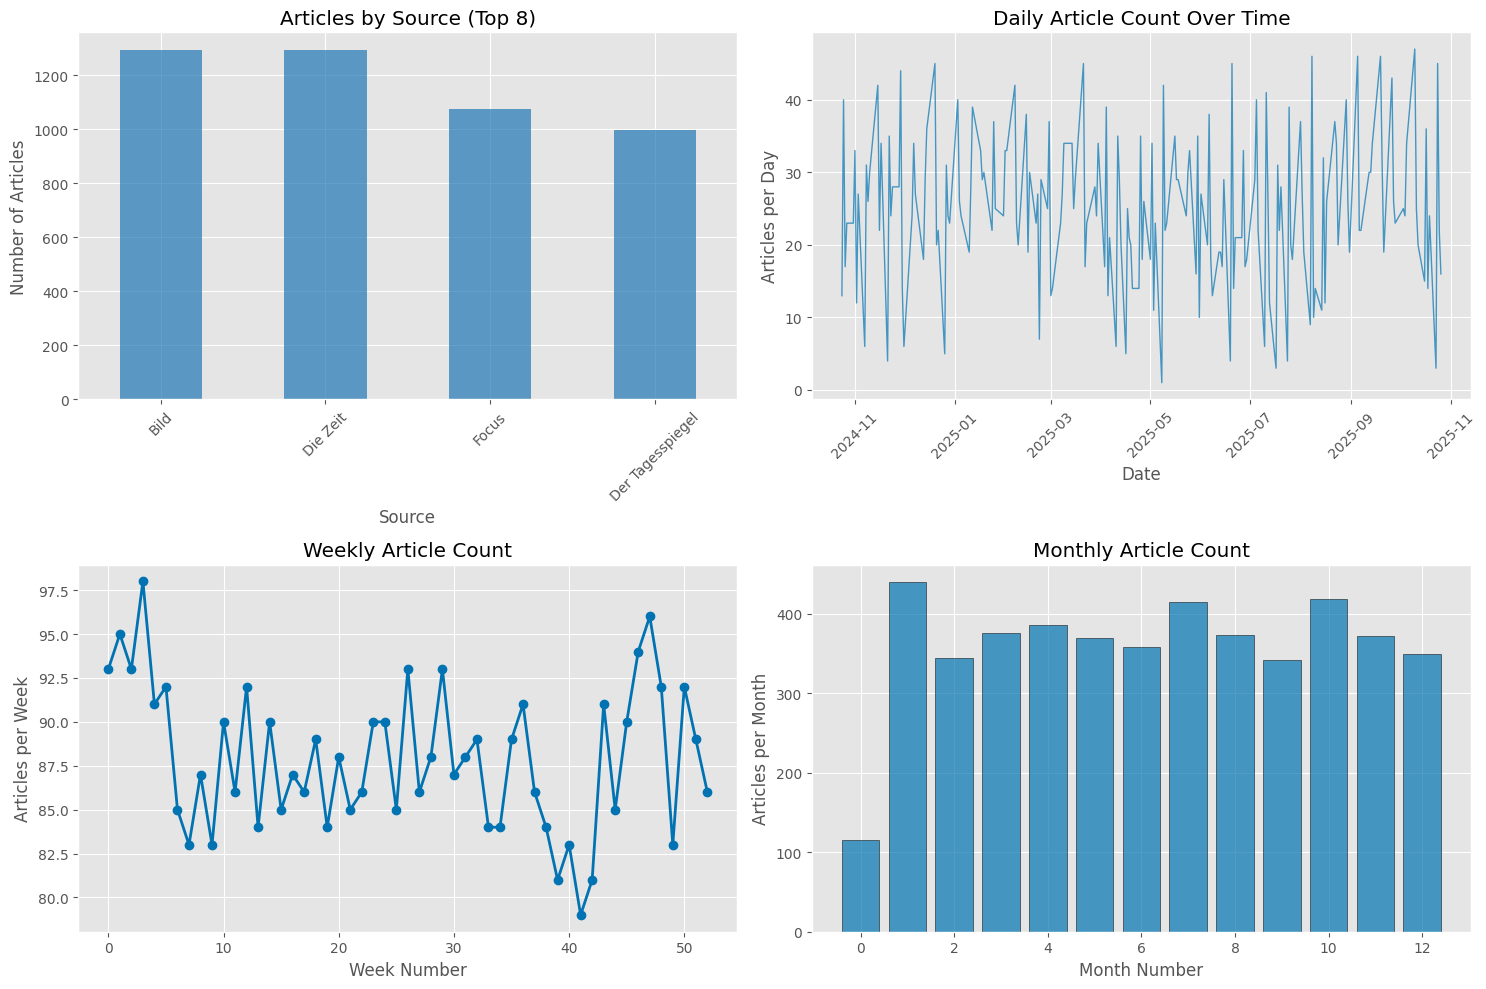


Temporal patterns:
  Peak daily count: 47 articles
  Average daily count: 25.1 articles
  Peak weekly count: 98 articles
  Average weekly count: 87.9 articles


In [5]:
# Summary statistics
print("="*60)
print("ARTICLE COUNT ANALYSIS")
print("="*60)
print(f"Total articles retrieved: {len(broad_news_df)}")
print(f"Date range: {broad_news_df['publishedAt'].min()} to {broad_news_df['publishedAt'].max()}")
print(f"Average articles per day: {len(broad_news_df) / ((broad_news_df['publishedAt'].max() - broad_news_df['publishedAt'].min()).days):.1f}")

# Source distribution
source_counts = broad_news_df['source'].value_counts()
print(f"\nTop sources:")
for source, count in source_counts.head(5).items():
    print(f"  {source}: {count} articles ({count/len(broad_news_df)*100:.1f}%)")

# Time series analysis
broad_news_df['date'] = broad_news_df['publishedAt'].dt.date
daily_counts = broad_news_df.groupby('date').size()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Source distribution
source_counts.head(8).plot(kind='bar', ax=axes[0,0], color='#1f77b4', alpha=0.7)
axes[0,0].set_title('Articles by Source (Top 8)')
axes[0,0].set_xlabel('Source')
axes[0,0].set_ylabel('Number of Articles')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Time series - daily counts
axes[0,1].plot(daily_counts.index, daily_counts.values, linewidth=1, alpha=0.7)
axes[0,1].set_title('Daily Article Count Over Time')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Articles per Day')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Weekly aggregation
weekly_counts = broad_news_df.groupby(broad_news_df['publishedAt'].dt.to_period('W')).size()
axes[1,0].plot(range(len(weekly_counts)), weekly_counts.values, marker='o', linewidth=2)
axes[1,0].set_title('Weekly Article Count')
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Articles per Week')

# 4. Monthly aggregation
monthly_counts = broad_news_df.groupby(broad_news_df['publishedAt'].dt.to_period('M')).size()
axes[1,1].bar(range(len(monthly_counts)), monthly_counts.values, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Monthly Article Count')
axes[1,1].set_xlabel('Month Number')
axes[1,1].set_ylabel('Articles per Month')

plt.tight_layout()
plt.show()

print(f"\nTemporal patterns:")
print(f"  Peak daily count: {daily_counts.max()} articles")
print(f"  Average daily count: {daily_counts.mean():.1f} articles")
print(f"  Peak weekly count: {weekly_counts.max()} articles")
print(f"  Average weekly count: {weekly_counts.mean():.1f} articles")


### 4.2 Content Analysis

CONTENT ANALYSIS
Total words analyzed: 109098
Unique words: 19304

Top 20 most frequent words:
  sie: 2935
  dem: 1545
  jetzt: 1299
  hier: 1145
  den: 1113
  lesen: 1045
  finden: 1030
  thema: 1013
  informationen: 995
  sich: 829
  aus: 567
  vor: 563
  als: 465
  des: 438
  wird: 406
  zum: 396
  energie: 382
  neue: 376
  fußball: 355
  vom: 354


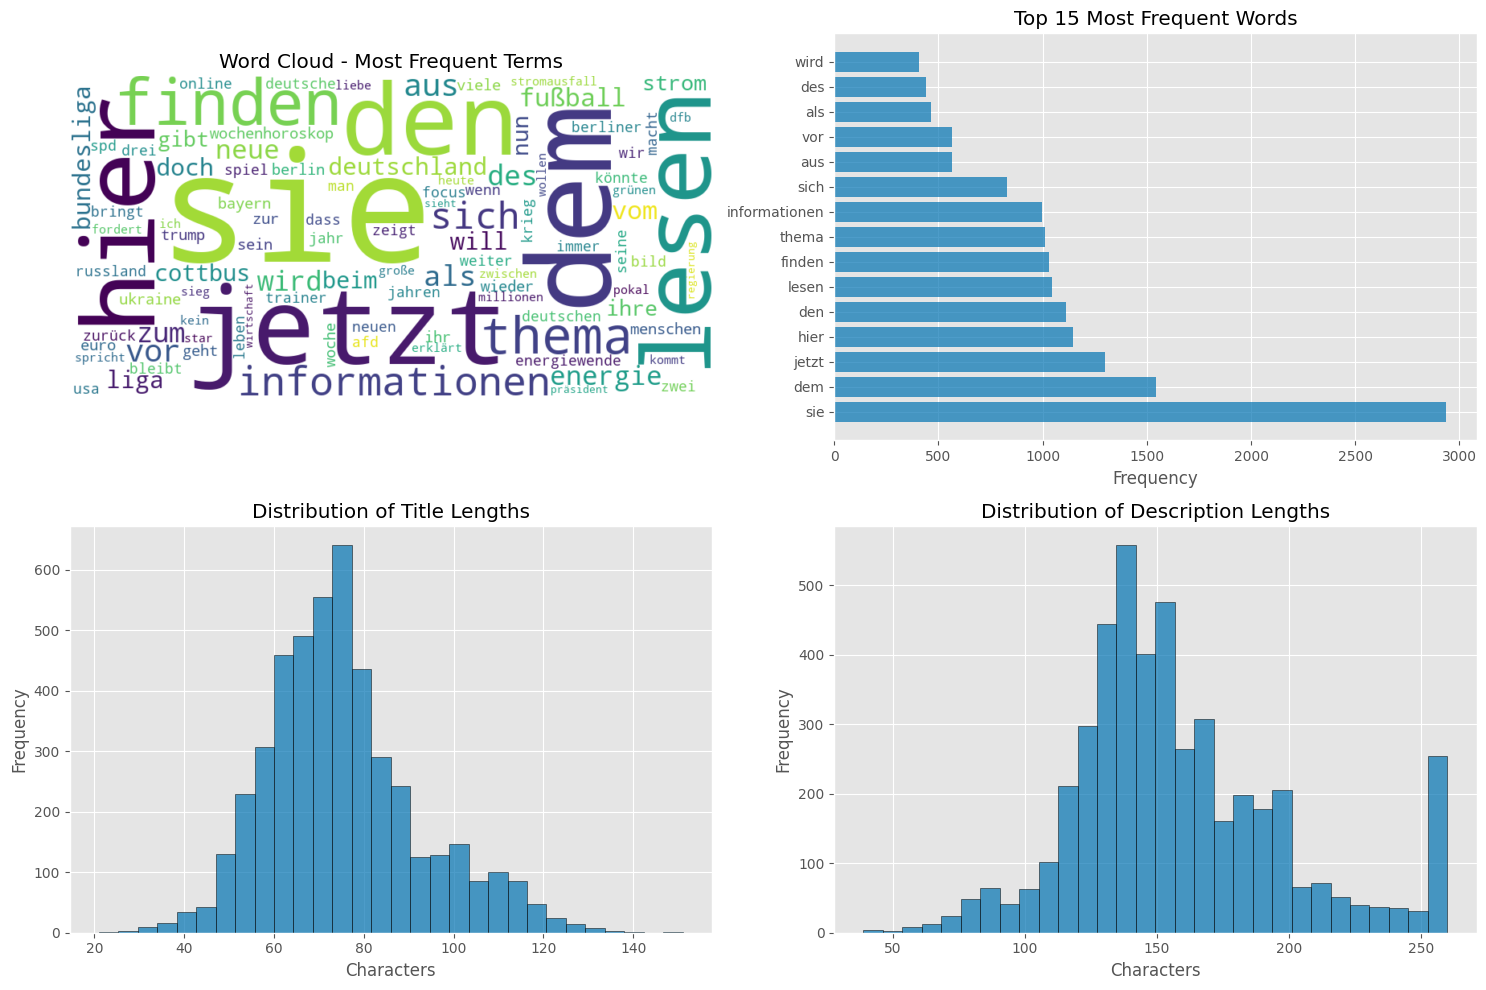


Text statistics:
  Average title length: 75.1 characters
  Average description length: 157.8 characters


In [6]:
# Combine all text for analysis
all_text = ' '.join(broad_news_df['title'].fillna('') + ' ' + broad_news_df['description'].fillna(''))

# German stopwords (basic set)
german_stopwords = {
    'der', 'die', 'das', 'und', 'oder', 'aber', 'mit', 'von', 'zu', 'in', 'auf', 'für', 'an', 'ist', 'sind', 
    'war', 'wurde', 'werden', 'kann', 'können', 'muss', 'müssen', 'soll', 'sollen', 'hat', 'haben', 'nach',
    'über', 'unter', 'bei', 'durch', 'gegen', 'ohne', 'um', 'bis', 'seit', 'während', 'trotz', 'wegen',
    'ein', 'eine', 'einen', 'einer', 'einem', 'eines', 'nicht', 'nur', 'auch', 'noch', 'schon', 'erst',
    'mehr', 'weniger', 'viel', 'wenig', 'alle', 'jeder', 'jede', 'jedes', 'manche', 'einige', 'keine',
    'dieser', 'diese', 'dieses', 'jener', 'jene', 'jenes', 'welcher', 'welche', 'welches', 'was', 'wer',
    'wie', 'wo', 'wann', 'warum', 'weshalb', 'wozu', 'wofür', 'womit', 'wovon', 'wozu', 'wodurch',
    # Additional stop words found in top results from output
    'sie', 'dem', 'den', 'des', 'vor', 'als', 'wird', 'zum', 'vom', 'zur', 'im', 'am', 'lesen',
    'finden', 'jetzt', 'hier', 'sich', 'aus', 'thema', 'informationen', 'neue', 'fußball',
    'seien', 'sein', 'seine', 'seinem', 'seinen', 'seines', 'kein', 'keine', 'keinen', 'keinem', 'keines',
    'habt', 'hast', 'bin', 'bist', 'waren', 'wart', 'warst', 'warten', 'warte'
}

# Clean and tokenize text
def clean_text(text):
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-ZäöüßÄÖÜ\s]', ' ', text.lower())
    # Split into words and filter
    words = [word for word in text.split() if len(word) > 2 and word not in german_stopwords]
    return words

words = clean_text(all_text)
word_freq = Counter(words)

print("="*60)
print("CONTENT ANALYSIS")
print("="*60)
print(f"Total words analyzed: {len(words)}")
print(f"Unique words: {len(word_freq)}")

# Top words
print(f"\nTop 20 most frequent words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Word cloud
if len(word_freq) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                         max_words=100, colormap='viridis').generate_from_frequencies(word_freq)
    axes[0,0].imshow(wordcloud, interpolation='bilinear')
    axes[0,0].axis('off')
    axes[0,0].set_title('Word Cloud - Most Frequent Terms')

# 2. Top words bar chart
top_words = dict(word_freq.most_common(15))
axes[0,1].barh(range(len(top_words)), list(top_words.values()), alpha=0.7)
axes[0,1].set_yticks(range(len(top_words)))
axes[0,1].set_yticklabels(list(top_words.keys()))
axes[0,1].set_title('Top 15 Most Frequent Words')
axes[0,1].set_xlabel('Frequency')

# 3. Title length distribution
title_lengths = broad_news_df['title'].str.len()
axes[1,0].hist(title_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].set_title('Distribution of Title Lengths')
axes[1,0].set_xlabel('Characters')
axes[1,0].set_ylabel('Frequency')

# 4. Description length distribution
desc_lengths = broad_news_df['description'].str.len()
axes[1,1].hist(desc_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Description Lengths')
axes[1,1].set_xlabel('Characters')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nText statistics:")
print(f"  Average title length: {title_lengths.mean():.1f} characters")
print(f"  Average description length: {desc_lengths.mean():.1f} characters")


### 4.3 Sample Headlines for Manual Review


In [7]:
# Display sample headlines for manual review
print("="*60)
print("SAMPLE HEADLINES FOR MANUAL REVIEW")
print("="*60)

# Show 30 random headlines
sample_size = min(30, len(broad_news_df))
sample_indices = np.random.choice(len(broad_news_df), sample_size, replace=False)
sample_df = broad_news_df.iloc[sample_indices].sort_values('publishedAt')

print(f"Showing {len(sample_df)} random headlines:")
print("-" * 60)

for i, (idx, row) in enumerate(sample_df.iterrows()):
    print(f"\n{i+1:2d}. [{row['source']}] {row['publishedAt'].strftime('%Y-%m-%d')}")
    print(f"    Title: {row['title']}")
    if pd.notna(row['description']) and len(str(row['description'])) > 0:
        desc = str(row['description'])[:150] + "..." if len(str(row['description'])) > 150 else str(row['description'])
        print(f"    Desc:  {desc}")
    print(f"    URL:   {row['url']}")

# Keyword match analysis
print(f"\n{'='*60}")
print("KEYWORD MATCH ANALYSIS")
print("="*60)

# Extract keywords from our search terms
search_keywords = ['Energie', 'Strom', 'Energiewende', 'Kraftwerk', 'Erneuerbare', 'Stromversorgung', 'Energieversorgung', 'Stromerzeugung', 'Energieerzeugung']

def count_keyword_matches(text, keywords):
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    matches = sum(1 for keyword in keywords if keyword.lower() in text_lower)
    return matches

# Count matches in titles and descriptions
broad_news_df['title_matches'] = broad_news_df['title'].apply(lambda x: count_keyword_matches(x, search_keywords))
broad_news_df['desc_matches'] = broad_news_df['description'].apply(lambda x: count_keyword_matches(x, search_keywords))
broad_news_df['total_matches'] = broad_news_df['title_matches'] + broad_news_df['desc_matches']

print(f"Keyword match statistics:")
print(f"  Articles with 0 matches: {(broad_news_df['total_matches'] == 0).sum()}")
print(f"  Articles with 1+ matches: {(broad_news_df['total_matches'] > 0).sum()}")
print(f"  Articles with 2+ matches: {(broad_news_df['total_matches'] >= 2).sum()}")
print(f"  Average matches per article: {broad_news_df['total_matches'].mean():.2f}")

# Show articles with most keyword matches
print(f"\nArticles with most keyword matches:")
top_matches = broad_news_df.nlargest(10, 'total_matches')[['title', 'source', 'total_matches']]
for i, (idx, row) in enumerate(top_matches.iterrows()):
    print(f"  {i+1:2d}. [{row['source']}] ({row['total_matches']} matches) {row['title']}")


SAMPLE HEADLINES FOR MANUAL REVIEW
Showing 30 random headlines:
------------------------------------------------------------

 1. [Der Tagesspiegel] 2024-10-25
    Title: Campino und seine Liebeserklärung an die Gebrauchslyrik: Der Junge von der Opel-Gang hat jetzt was zu sagen
    Desc:  „Kästner, Kraftwerk, Cock Sparrer“: Campinos Vorlesung an der Düsseldorfer Heinrich-Heine-Universität dreht sich nicht nur um Musik und Lyrik, sondern...
    URL:   https://www.tagesspiegel.de/campino-und-seine-liebeserklarung-an-die-gebrauchslyrik-der-junge-von-der-opel-gang-hat-jetzt-was-zu-sagen-12594014.html

 2. [Die Zeit] 2024-10-26
    Title: Im März vom Netz gegangen: Teile des Kohlekraftwerks Mehrum erfolgreich gesprengt
    Desc:  Hier finden Sie Informationen zu dem Thema „Im März vom Netz gegangen“. Lesen Sie jetzt „Teile des Kohlekraftwerks Mehrum erfolgreich gesprengt“.
    URL:   https://www.zeit.de/news/2024-10/26/teile-des-kohlekraftwerks-mehrum-erfolgreich-gesprengt

 3. [Der Tagessp

## 5. BERTopic Analysis for Topic Discovery


In [8]:
if bertopic_available and len(broad_news_df) > 0:
    print("="*60)
    print("BERTOPIC ANALYSIS")
    print("="*60)
    
    # Prepare documents for BERTopic
    documents = []
    for idx, row in broad_news_df.iterrows():
        # Combine title and description
        doc = str(row['title'])
        if pd.notna(row['description']) and len(str(row['description'])) > 0:
            doc += " " + str(row['description'])
        documents.append(doc)
    
    print(f"Prepared {len(documents)} documents for topic modeling")
    
    # Initialize BERTopic with German-compatible model
    print("Initializing BERTopic with German language model...")
    model = BERTopic(
        embedding_model="paraphrase-multilingual-MiniLM-L12-v2",
        language="german",
        calculate_probabilities=True,
        verbose=True
    )
    
    # Fit the model
    print("Fitting BERTopic model...")
    topics, probs = model.fit_transform(documents)
    
    # Get topic information
    topic_info = model.get_topic_info()
    print(f"\n✓ BERTopic analysis complete!")
    print(f"✓ Discovered {len(topic_info)} topics")
    
    # Display topic information
    print(f"\nTopic Overview:")
    print("-" * 60)
    for idx, row in topic_info.iterrows():
        print(f"Topic {row['Topic']:2d}: {row['Count']:4d} documents - {row['Name']}")
    
    # Show detailed topics
    print(f"\nDetailed Topic Analysis:")
    print("=" * 60)
    
    for topic_id in range(len(topic_info)):
        if topic_id == -1:  # Skip outlier topic
            continue
            
        print(f"\nTopic {topic_id}:")
        print("-" * 40)
        
        # Get top words for this topic
        words = model.get_topic(topic_id)
        if words:
            print("Top words:", ", ".join([word[0] for word in words[:10]]))
        
        # Get representative documents
        topic_docs = broad_news_df[topics == topic_id]
        if len(topic_docs) > 0:
            print(f"Sample headlines ({len(topic_docs)} total):")
            for i, (idx, row) in enumerate(topic_docs.head(5).iterrows()):
                print(f"  {i+1}. [{row['source']}] {row['title']}")
    
    # Create topic visualization
    print(f"\nGenerating topic visualizations...")
    
    # Topic size visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Topic sizes
    topic_counts = [len(broad_news_df[topics == topic_id]) for topic_id in range(len(topic_info))]
    topic_labels = [f"Topic {i}" for i in range(len(topic_info))]
    
    axes[0,0].bar(range(len(topic_counts)), topic_counts, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('Documents per Topic')
    axes[0,0].set_xlabel('Topic ID')
    axes[0,0].set_ylabel('Number of Documents')
    axes[0,0].set_xticks(range(len(topic_counts)))
    axes[0,0].set_xticklabels(topic_labels, rotation=45)
    
    # 2. Topic distribution over time
    broad_news_df['topic'] = topics
    broad_news_df['month'] = broad_news_df['publishedAt'].dt.to_period('M')
    topic_time = broad_news_df.groupby(['month', 'topic']).size().unstack(fill_value=0)
    
    if len(topic_time.columns) > 0:
        topic_time.plot(kind='bar', stacked=True, ax=axes[0,1], alpha=0.7)
        axes[0,1].set_title('Topic Distribution Over Time')
        axes[0,1].set_xlabel('Month')
        axes[0,1].set_ylabel('Number of Documents')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Topic distribution by source
    topic_source = broad_news_df.groupby(['source', 'topic']).size().unstack(fill_value=0)
    if len(topic_source.columns) > 0:
        topic_source.plot(kind='bar', ax=axes[1,0], alpha=0.7)
        axes[1,0].set_title('Topic Distribution by Source')
        axes[1,0].set_xlabel('Source')
        axes[1,0].set_ylabel('Number of Documents')
        axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Topic similarity (if available)
    try:
        model.visualize_topics().show()
    except:
        axes[1,1].text(0.5, 0.5, 'Topic similarity visualization\nnot available', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Topic Similarity')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ BERTopic analysis complete!")
    print(f"✓ Use the topic information above to identify relevant topics for:")
    print(f"  - Energy production (Kraftwerk, Solar, Wind, etc.)")
    print(f"  - Energy consumption (Verbrauch, Bedarf, etc.)")
    print(f"  - Energy policy/pricing (Preis, Politik, etc.)")
    
else:
    print("⚠️  BERTopic not available or no data to analyze")
    print("Please install BERTopic: pip install bertopic sentence-transformers")


2025-10-26 16:11:55,130 - BERTopic - Embedding - Transforming documents to embeddings.


BERTOPIC ANALYSIS
Prepared 4661 documents for topic modeling
Initializing BERTopic with German language model...
Fitting BERTopic model...


Batches: 100%|██████████| 146/146 [00:09<00:00, 14.75it/s]
2025-10-26 16:12:08,405 - BERTopic - Embedding - Completed ✓
2025-10-26 16:12:08,405 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-26 16:12:19,661 - BERTopic - Dimensionality - Completed ✓
2025-10-26 16:12:19,662 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-26 16:12:20,590 - BERTopic - Cluster - Completed ✓
2025-10-26 16:12:20,595 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-26 16:12:20,695 - BERTopic - Representation - Completed ✓



✓ BERTopic analysis complete!
✓ Discovered 98 topics

Topic Overview:
------------------------------------------------------------
Topic -1: 1655 documents - -1_die_der_in_und
Topic  0:  155 documents - 0_erneuerbare_energiewende_energien_informationen
Topic  1:  140 documents - 1_ukraine_russland_krieg_putin
Topic  2:  131 documents - 2_abnehmen_körper_erklärt_wie
Topic  3:  129 documents - 3_klimaschutz_klima_co2_klimakrise
Topic  4:  122 documents - 4_auto_autos_iaa_suv
Topic  5:  111 documents - 5_wirtschaft_deutschland_deutsche_industrie
Topic  6:   86 documents - 6_spd_union_cdu_csu
Topic  7:   81 documents - 7_bundesliga_fußball_leipzig_informationen
Topic  8:   80 documents - 8_liga_cottbus_fußball_informationen
Topic  9:   69 documents - 9_feuer_brand_feuerwehr_brände
Topic 10:   61 documents - 10_stromausfall_unfall_notrufe_stromschlag
Topic 11:   56 documents - 11_afd_musk_weidel_elon
Topic 12:   49 documents - 12_elbvertiefung_berlin_buchstabenmuseum_hamburg
Topic 13:   47

KeyError: False

## 6. Manual Keyword Refinement & Testing


KEYWORD REFINEMENT & TESTING
Refined keyword sets defined:

1. PRODUCTION:
   "Solar" OR "Windkraft" OR "Atomkraft" OR "Kohlekraftwerk" OR "Gaskraftwerk" OR "Erneuerbare Energie" OR "Photovoltaik" OR "Windpark" OR "Kernkraftwerk" OR "Biomasse" OR "Wasserkraft"

2. CONSUMPTION:
   "Stromverbrauch" OR "Energieverbrauch" OR "Strombedarf" OR "Stromnachfrage" OR "Netzlast" OR "Lastspitzen" OR "Stromverbrauch" OR "Energieeffizienz" OR "Stromsparen"

3. POLICY/PRICING:
   "Strompreis" OR "Energiepreis" OR "Energiepolitik" OR "Energiewende" OR "Stromkosten" OR "Energiesteuer" OR "EEG" OR "Energiegesetz" OR "Strommarkt"

4. COMBINED:
   "Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR "Erneuerbare" OR "Stromversorgung" OR "Strompreis" OR "Stromverbrauch" OR "Energiepolitik"

TESTING REFINED KEYWORD SETS

Testing Production keywords...
Keywords: "Solar" OR "Windkraft" OR "Atomkraft" OR "Kohlekraftwerk" OR "Gaskraftwerk" OR "Erneuerbare Energie" OR "Photovoltaik" OR "Windpark" OR "Kernkra

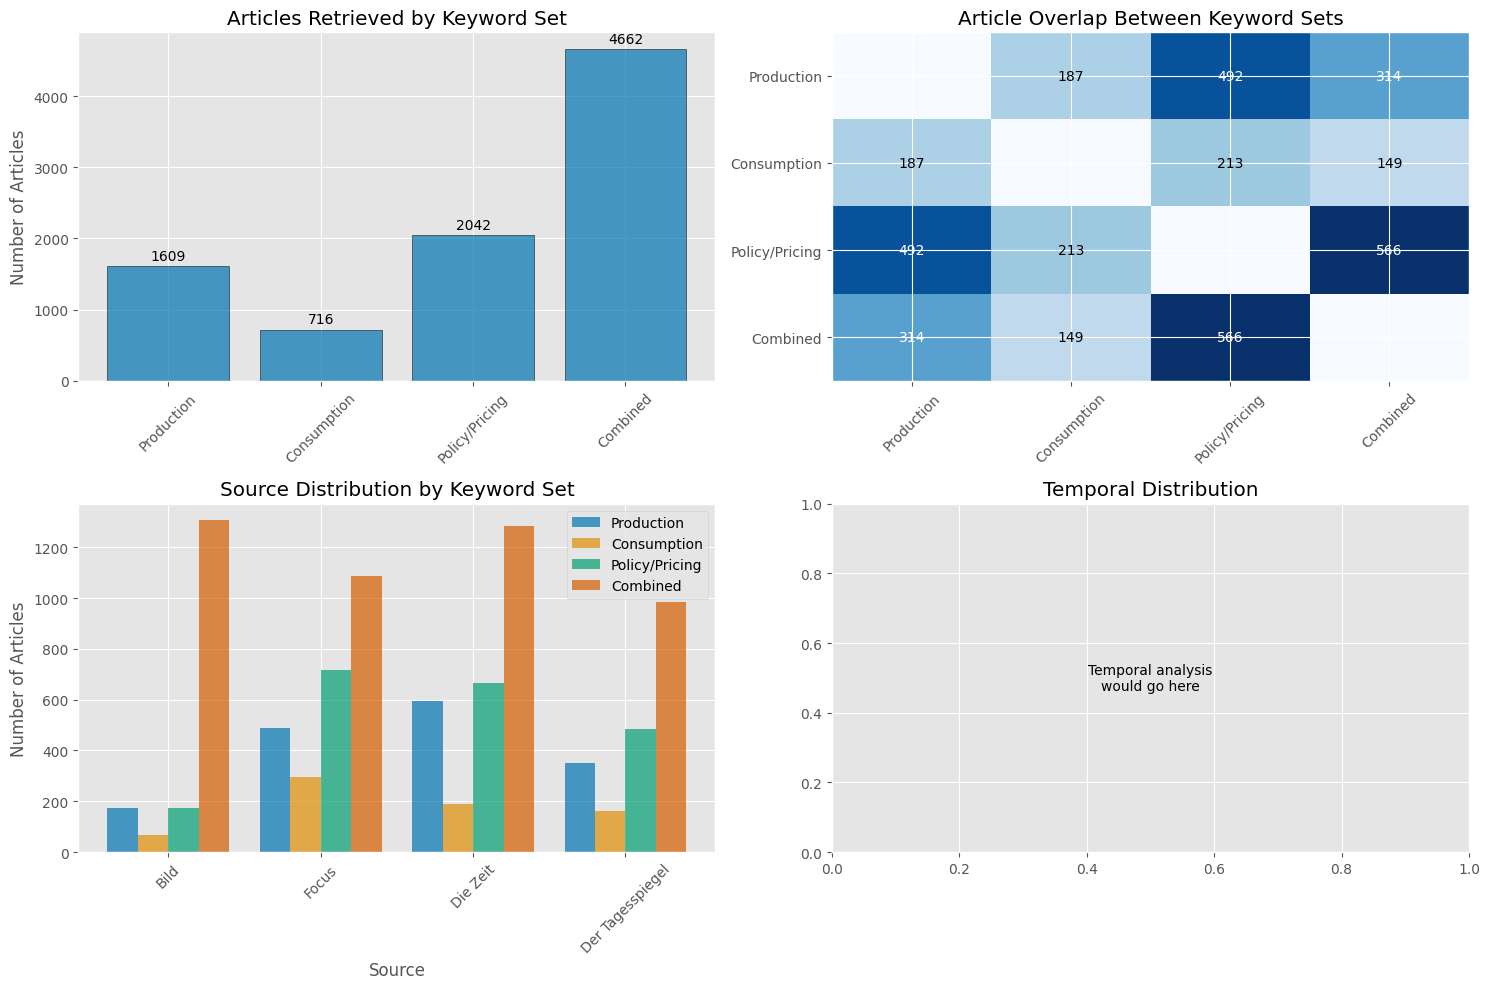


✓ Keyword testing complete!
✓ Use the results above to select the most effective keyword combinations


In [9]:
# Define refined keyword sets based on analysis
print("="*60)
print("KEYWORD REFINEMENT & TESTING")
print("="*60)

# Refined keyword combinations
PRODUCTION_KEYWORDS = (
    '"Solar" OR "Windkraft" OR "Atomkraft" OR "Kohlekraftwerk" OR '
    '"Gaskraftwerk" OR "Erneuerbare Energie" OR "Photovoltaik" OR '
    '"Windpark" OR "Kernkraftwerk" OR "Biomasse" OR "Wasserkraft"'
)

CONSUMPTION_KEYWORDS = (
    '"Stromverbrauch" OR "Energieverbrauch" OR "Strombedarf" OR '
    '"Stromnachfrage" OR "Netzlast" OR "Lastspitzen" OR "Stromverbrauch" OR '
    '"Energieeffizienz" OR "Stromsparen"'
)

POLICY_PRICING_KEYWORDS = (
    '"Strompreis" OR "Energiepreis" OR "Energiepolitik" OR '
    '"Energiewende" OR "Stromkosten" OR "Energiesteuer" OR '
    '"EEG" OR "Energiegesetz" OR "Strommarkt"'
)

# Combined comprehensive set
COMBINED_KEYWORDS = (
    '"Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR '
    '"Erneuerbare" OR "Stromversorgung" OR "Strompreis" OR '
    '"Stromverbrauch" OR "Energiepolitik"'
)

print("Refined keyword sets defined:")
print(f"\n1. PRODUCTION:")
print(f"   {PRODUCTION_KEYWORDS}")
print(f"\n2. CONSUMPTION:")
print(f"   {CONSUMPTION_KEYWORDS}")
print(f"\n3. POLICY/PRICING:")
print(f"   {POLICY_PRICING_KEYWORDS}")
print(f"\n4. COMBINED:")
print(f"   {COMBINED_KEYWORDS}")

# Test each keyword set if API key is available
if NEWS_API_KEY:
    print(f"\n{'='*60}")
    print("TESTING REFINED KEYWORD SETS")
    print("="*60)
    
    keyword_sets = {
        'Production': PRODUCTION_KEYWORDS,
        'Consumption': CONSUMPTION_KEYWORDS,
        'Policy/Pricing': POLICY_PRICING_KEYWORDS,
        'Combined': COMBINED_KEYWORDS
    }
    
    results = {}
    
    for name, keywords in keyword_sets.items():
        print(f"\nTesting {name} keywords...")
        print(f"Keywords: {keywords}")
        
        # Fetch data for this keyword set
        test_df = fetch_news_data(
            start_date.strftime('%Y-%m-%d'),
            end_date.strftime('%Y-%m-%d'),
            keywords,
            NEWS_API_KEY
        )
        
        results[name] = {
            'keywords': keywords,
            'count': len(test_df),
            'df': test_df
        }
        
        print(f"✓ {name}: {len(test_df)} articles retrieved")
        
        # Show sample headlines
        if len(test_df) > 0:
            print(f"Sample headlines:")
            for i, (idx, row) in enumerate(test_df.head(3).iterrows()):
                print(f"  {i+1}. [{row['source']}] {row['title']}")
    
    # Compare results
    print(f"\n{'='*60}")
    print("KEYWORD SET COMPARISON")
    print("="*60)
    
    comparison_data = []
    for name, data in results.items():
        comparison_data.append({
            'Keyword Set': name,
            'Articles Retrieved': data['count'],
            'Keywords': data['keywords']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Article count comparison
    names = list(results.keys())
    counts = [results[name]['count'] for name in names]
    
    axes[0,0].bar(names, counts, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('Articles Retrieved by Keyword Set')
    axes[0,0].set_ylabel('Number of Articles')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for i, count in enumerate(counts):
        axes[0,0].text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom')
    
    # 2. Overlap analysis (if we have multiple sets)
    if len(results) > 1:
        # Calculate overlaps between sets
        overlap_matrix = np.zeros((len(results), len(results)))
        result_names = list(results.keys())
        
        for i, name1 in enumerate(result_names):
            for j, name2 in enumerate(result_names):
                if i != j:
                    df1 = results[name1]['df']
                    df2 = results[name2]['df']
                    # Calculate overlap based on title similarity
                    overlap = len(set(df1['title']) & set(df2['title']))
                    overlap_matrix[i, j] = overlap
        
        im = axes[0,1].imshow(overlap_matrix, cmap='Blues', aspect='auto')
        axes[0,1].set_xticks(range(len(result_names)))
        axes[0,1].set_yticks(range(len(result_names)))
        axes[0,1].set_xticklabels(result_names, rotation=45)
        axes[0,1].set_yticklabels(result_names)
        axes[0,1].set_title('Article Overlap Between Keyword Sets')
        
        # Add text annotations
        for i in range(len(result_names)):
            for j in range(len(result_names)):
                if i != j:
                    axes[0,1].text(j, i, int(overlap_matrix[i, j]), 
                                  ha='center', va='center', color='white' if overlap_matrix[i, j] > overlap_matrix.max()/2 else 'black')
    
    # 3. Source distribution comparison
    source_comparison = {}
    for name, data in results.items():
        if len(data['df']) > 0:
            source_counts = data['df']['source'].value_counts()
            source_comparison[name] = source_counts
    
    if source_comparison:
        # Plot top sources for each keyword set
        all_sources = set()
        for sources in source_comparison.values():
            all_sources.update(sources.index)
        
        top_sources = list(all_sources)[:5]  # Top 5 sources across all sets
        
        x = np.arange(len(top_sources))
        width = 0.2
        
        for i, (name, sources) in enumerate(source_comparison.items()):
            counts = [sources.get(source, 0) for source in top_sources]
            axes[1,0].bar(x + i*width, counts, width, label=name, alpha=0.7)
        
        axes[1,0].set_xlabel('Source')
        axes[1,0].set_ylabel('Number of Articles')
        axes[1,0].set_title('Source Distribution by Keyword Set')
        axes[1,0].set_xticks(x + width * (len(source_comparison)-1) / 2)
        axes[1,0].set_xticklabels(top_sources, rotation=45)
        axes[1,0].legend()
    
    # 4. Temporal distribution
    axes[1,1].text(0.5, 0.5, 'Temporal analysis\nwould go here', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Temporal Distribution')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Keyword testing complete!")
    print(f"✓ Use the results above to select the most effective keyword combinations")
    
else:
    print("⚠️  Cannot test keywords without NewsAPI key")
    print("Please add NEWSAPIORG_KEY to your .env file")
